# 26. Интервалы прогноза: квантильный бустинг и конформная калибровка (CQR)

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`26_prediction_intervals.py`](../26_prediction_intervals.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Выдавать не только число, но и честный диапазон «цена будет от … до … с вероятностью 90%».

### Чему вы научитесь

- Квантильная потеря (pinball) для нижней и верхней границ
- Проверка покрытия и ширины
- Конформная калибровка (CQR) на отдельной выборке — гарантия покрытия без предположений о распределении
- Почему интервал постоянной ширины плох при неоднородном шуме

### Данные

`_data.make_houses` — 40 000 квартир; цель — цена в млн (не логарифм): шум мультипликативный, поэтому у дорогих квартир разброс в рублях больше — интервалы должны расширяться.

### План

1. **Этап 1.** Данные: обучение 50%, валидация 10%, калибровка 20%, тест 20%
2. **Этап 2.** Простейший вариант: точечная модель ± квантиль |ошибки| на калибровке (split conformal)
3. **Этап 3.** Квантильный бустинг: отдельные модели для 5% и 95%
4. **Этап 4.** Конформная калибровка квантилей (CQR): расширяем границы на квантиль ошибок калибровки
5. **Этап 5.** Покрытие по ценовым группам: главное отличие адаптивных интервалов
6. **Этап 6.** Выводы

> Ноутбук собран из `examples/4_large/26_prediction_intervals.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "4_large/26_prediction_intervals.py", title="26. Интервалы прогноза: квантили и CQR",
             goal="выдавать прогноз с честным интервалом на 90%")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from gbcourse.style import ROLE

ALPHA = 0.10                                                  # хотим покрытие 90%

## Этап 1. Данные: обучение 50%, валидация 10%, калибровка 20%, тест 20%

In [2]:
X, y = make_houses(ex.size(40_000, 10_000), seed=26)
ex.describe(X, y, target="цена, млн", source="examples/_data.py → make_houses")
n = len(y)
perm = np.random.default_rng(0).permutation(n)
tr, va, cal, te = np.split(perm, [int(0.5 * n), int(0.6 * n), int(0.8 * n)])


def fit(objective, **kw):
    m = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          objective=objective, verbose=-1, random_state=0, **kw)
    m.fit(X.iloc[tr], y[tr], eval_X=(X.iloc[va],), eval_y=(y[va],), callbacks=[lgb.early_stopping(100, verbose=False)])
    return m


def conformal_q(scores):
    """Квантиль ошибок калибровки с поправкой на конечную выборку: гарантирует покрытие ≥ 1 − α."""
    k = int(np.ceil((len(scores) + 1) * (1 - ALPHA)))
    return float(np.sort(scores)[min(k, len(scores)) - 1])


def report(name, lo, hi):
    cover = np.mean((y[te] >= lo) & (y[te] <= hi))
    print(f"   {name:34s} покрытие {cover:.3f}  средняя ширина {np.mean(hi - lo):.2f} млн")
    return cover

   Источник: examples/_data.py → make_houses
   Объектов: 40 000   признаков: 10   память: 2.52 МБ
   Типы признаков: int64 × 5, float64 × 3, category × 2
   Пропуски: кухня 5.0%
   Цель «цена, млн»: среднее 8.818, σ 4.137, мин 1.096, макс 34.498
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,"[цена, млн]"
0,90.7,4,5,5,1976,11.71,район_03,0,косметический,13.6,8.655
1,69.3,3,5,9,1988,2.43,район_00,0,без ремонта,11.4,11.603
2,45.4,2,13,17,2021,8.99,район_00,1,евро,7.0,7.711


## Этап 2. Простейший вариант: точечная модель ± квантиль |ошибки| на калибровке (split conformal)

In [3]:
point = fit("regression")
q_abs = conformal_q(np.abs(y[cal] - point.predict(X.iloc[cal])))
p_te = point.predict(X.iloc[te])
report("точка ± постоянная ширина", p_te - q_abs, p_te + q_abs)

   точка ± постоянная ширина          покрытие 0.903  средняя ширина 2.70 млн


np.float64(0.902625)

## Этап 3. Квантильный бустинг: отдельные модели для 5% и 95%

In [4]:
m_lo, m_hi = fit("quantile", alpha=ALPHA / 2), fit("quantile", alpha=1 - ALPHA / 2)
lo_te, hi_te = m_lo.predict(X.iloc[te]), m_hi.predict(X.iloc[te])
report("квантильный бустинг", lo_te, hi_te)
ex.note("Квантильные модели обучены на ограниченных данных и с ранней остановкой — покрытие не гарантировано.")

   квантильный бустинг                покрытие 0.817  средняя ширина 2.27 млн


> ▸ **Вывод.** Квантильные модели обучены на ограниченных данных и с ранней остановкой — покрытие не гарантировано.

## Этап 4. Конформная калибровка квантилей (CQR): расширяем границы на квантиль ошибок калибровки

In [5]:
lo_c, hi_c = m_lo.predict(X.iloc[cal]), m_hi.predict(X.iloc[cal])
E = np.maximum(lo_c - y[cal], y[cal] - hi_c)                  # > 0, если точка вне интервала
qE = conformal_q(E)
print(f"   поправка границ: {qE:+.3f} млн (плюс — расширить, минус — сузить)")
cover_cqr = report("CQR", lo_te - qE, hi_te + qE)
assert cover_cqr > 0.88

   поправка границ: +0.217 млн (плюс — расширить, минус — сузить)
   CQR                                покрытие 0.897  средняя ширина 2.71 млн


## Этап 5. Покрытие по ценовым группам: главное отличие адаптивных интервалов

   группа по прогнозу   постоянная ширина   CQR (покрытие / ширина)
   дешёвые 25%          0.998 /  2.70      0.940 /  1.60
   ниже медианы         0.976 /  2.70      0.893 /  2.09
   выше медианы         0.905 /  2.70      0.887 /  2.73
   дорогие 25%          0.732 /  2.70      0.868 /  4.41


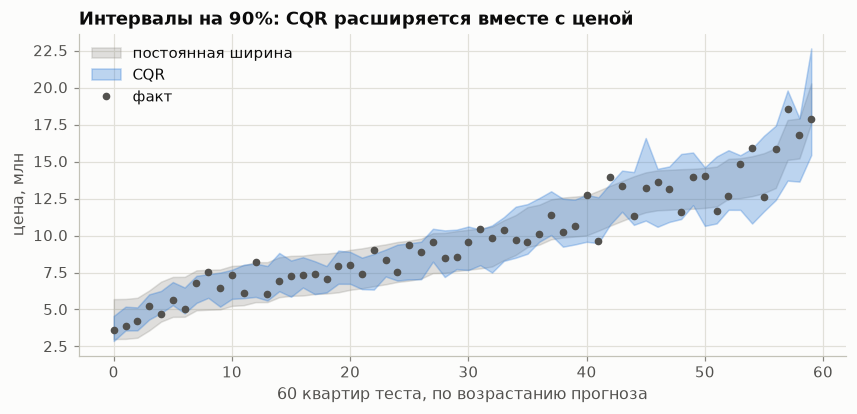

In [6]:
groups = np.digitize(p_te, np.quantile(p_te, [0.25, 0.5, 0.75]))
print("   группа по прогнозу   постоянная ширина   CQR (покрытие / ширина)")
for gi, name in enumerate(("дешёвые 25%", "ниже медианы", "выше медианы", "дорогие 25%")):
    k = groups == gi
    c1 = np.mean(np.abs(y[te][k] - p_te[k]) <= q_abs)
    lo, hi = lo_te[k] - qE, hi_te[k] + qE
    c2 = np.mean((y[te][k] >= lo) & (y[te][k] <= hi))
    print(f"   {name:18s}   {c1:.3f} / {2 * q_abs:5.2f}      {c2:.3f} / {np.mean(hi - lo):5.2f}")

fig, ax = plt.subplots(figsize=(9, 3.8))
idx = np.sort(np.random.default_rng(0).choice(len(te), 60, replace=False))
idx = idx[np.argsort(p_te[idx])]
xs = np.arange(len(idx))
ax.fill_between(xs, p_te[idx] - q_abs, p_te[idx] + q_abs, color=ROLE["truth"], alpha=0.25, label="постоянная ширина")
ax.fill_between(xs, lo_te[idx] - qE, hi_te[idx] + qE, color=ROLE["model"], alpha=0.3, label="CQR")
ax.plot(xs, y[te][idx], "o", color=ROLE["data"], ms=4, label="факт")
ax.set(xlabel="60 квартир теста, по возрастанию прогноза", ylabel="цена, млн",
       title="Интервалы на 90%: CQR расширяется вместе с ценой")
ax.legend()
ex.finish(fig, "26_intervals")

## Этап 6. Выводы

In [7]:
ex.note("""Интервал постоянной ширины даёт 90% в среднем, но избыточен для дешёвых квартир и узок для дорогих.
Квантильный бустинг подстраивает ширину под объект; конформная поправка по отдельной выборке возвращает гарантию
среднего покрытия. Калибровочные данные нельзя использовать для обучения и ранней остановки.""")
ex.done()

> ▸ **Вывод.** Интервал постоянной ширины даёт 90% в среднем, но избыточен для дешёвых квартир и узок для дорогих. Квантильный бустинг подстраивает ширину под объект; конформная поправка по отдельной выборке возвращает гарантию среднего покрытия. Калибровочные данные нельзя использовать для обучения и ранней остановки.

Готово за 2.6 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Поставьте ALPHA = 0.2 (интервал на 80%) и проверьте покрытие.
2. Уменьшите калибровочную выборку до 200 объектов и повторите с разными seed — насколько гуляет покрытие?
3. Обучите квантили на `log(цены)` и переведите границы обратно через exp.

## Что дальше

- **Теория в курсе:** [5.3 «Потери для регрессии»](../../../lessons/lesson_5_3/README.md) (квантильная), [13.2 «Калибровка и интервалы»](../../../lessons/lesson_13_2/README.md).
- **Предыдущий пример:** [25. Страхование: частота (Пуассон), ущерб (Твиди), экспозиция — 200 000 полисов](25_insurance_poisson_tweedie.ipynb)
- **Следующий пример:** [27. Ограничения из знаний о предметной области: монотонность и запрет взаимодействий](27_monotone_and_interaction_constraints.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)